In [1]:
# # Daily forecast of financial time series group questions

import matplotlib.pylab as plt
from get_market_pulse_25q3_questions import get_market_pulse_25q3_questions
from get_underlying_urls import get_underlying_urls
from urls_to_ticker import urls_to_ticker
from pprint import pprint
from get_data_for import get_data_for
from get_forward_period_start_and_end_date import get_forward_period_start_and_end_date
from get_observable import get_observable
from get_period_type import get_period_type
import pandas as pd
from forecast_high_on_any_day_in_forward_period import forecast_high_on_any_day_in_forward_period
from forecast_close_on_last_day_of_period import forecast_close_on_last_day_of_period
from forecast_stock_price_return_spread import forecast_stock_price_return_spread
from forecast_futures_total_price_return_spread import forecast_futures_total_price_return_spread
from forecast_quarter_diluted_eps_on_next_filing_date import forecast_quarter_diluted_eps_on_next_filing_date
from metaculus_generate_continuous_cdf import metaculus_generate_continuous_cdf
from standardize_cdf import standardize_cdf
from post_group_forecast import post_group_forecast
from forecast_general_binary import forecast_general_binary
from ensure_min_increase import ensure_min_increase
import os

pd.set_option('display.max_colwidth', 1000)

# Get open questions
ifps = get_market_pulse_25q3_questions()
results = get_underlying_urls(ifps)
results = {int(key): value for key, value in results.items()}
group_id_to_data = {int(x): results[x] for x in results}

# Acquire question data
sources = []
for key, (title, urls) in results.items():
    sources.extend(urls_to_ticker(urls))

sources = list(sorted(set(sources)))
history = {(x,y,z): get_data_for(x,y,z) for x,y,z in sources}

loading massive wiki index 2025-07-26 19:31:18.380383
loading wiki article titles 2025-07-26 19:31:38.799351
loading sentence transformer model 2025-07-26 19:31:42.116596
done 2025-07-26 19:31:43.831385
200
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.1453472336133321

Here are the URLs of the data sources mentioned in the question:

```python
[
    "https://en.wikipedia.org/wiki/S%26P_500",
    "https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices",
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S%26P_500_component_stocks",
    "https://en.wikipedia.org/wiki/Ares_Management",
    "https://en.wikipedia.org/wiki/MicroStrategy",
    "https://en.wikipedia.org/wiki/The_Trade_Desk",
    "https://en.wikipedia.org/wiki/Robinhood_Markets",
    "https://en.wikipedia.org/wiki/Datadog",
    "https://www.spglobal.com/"
]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2

/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  

In [2]:
for i, ifp in enumerate(ifps):
    # Organize data
    ifp['sources'] = urls_to_ticker(results[ifp['group']['id']][1])

DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S%26P_500_component_stocks
DK https://en.wikipedia.org/wiki/Ares_Management
DK https://en.wikipedia.org/wiki/MicroStrategy
DK https://en.wikipedia.org/wiki/The_Trade_Desk
DK https://en.wikipedia.org/wiki/Robinhood_Markets
DK https://en.wikipedia.org/wiki/Datadog
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S%26P_500_component_stocks
DK https://en.wikipedia.org/wiki/Ares_Management
DK https://en.wikipedia.org/wiki/MicroStrategy
DK https://en.wikipedia.org/wiki/The_Trade_Desk
DK https://en.wikipedia.org/wiki/Robinhood_Markets
DK https://en.wikipedia.org/wiki/Datadog
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_In

In [3]:
for i, ifp in enumerate(ifps):
    ifp['data'] = {x: history[x] for x in ifp['sources']}

In [4]:
for i, ifp in enumerate(ifps):
    if 'following companies' in ifp['title']:
        company = ifp['title'].split('(')[1].split(')')[0]
        ifp['sources'] = [(x,y,z) for x,y,z in ifp['sources'] if y == company]
        ifp['data'] = {(x,y,z):w for (x,y,z),w in ifp['data'].items() if y == company}

In [5]:
ifp['sources']

[('macrotrends', 'AMZN', 'revenue')]

In [6]:
for i, ifp in enumerate(ifps):
    # Get forward period start and end date
    if 'period' not in ifp or not ifp['period']:
        ifp['period'] = get_forward_period_start_and_end_date(ifp)

hi
Today is 2025-07-26.  Please return, as python strings, in format YYYY-MM-DD, 
the start date and end date of the period "ARES", in format
```python
[startDate,endDate]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.013771156469980875

I'm sorry, but I don't have information about the period "ARES" in my knowledge base. Could you please provide more context or details about what "ARES" refers to? This will help me assist you better.

Today is 2025-07-26.
For the period from today to the ending time referred to in this question:

Will the following companies be added to the S&P 500 before October 2025? (ARES)

please return, as python strings, in format YYYY-MM-DD, 
the start date and end date of the period mentioned, in format
```python
[startDate,endDate]
```
Any symbol or name you see in the query refers to a US listed equity (company listed on a stock exchange).

START model mistral-small3.2:24b-instruct-2506-q4

In [7]:
for i, ifp in enumerate(ifps):
    # Parse observable of data
    if 'observable' not in ifp:
        ifp['observable'] = get_observable(ifp)

In [8]:
for i, ifp in enumerate(ifps):
    if 'period_type' not in ifp:
        ifp['period_type'] = get_period_type(ifp)

[0] Will the following companies be added to the S&P 500 before October 2025? (ARES)
already forecast: 37913 Will the following companies be added to the S&P 500 before October 2025? (ARES)
[1] Will the following companies be added to the S&P 500 before October 2025? (HOOD)
already forecast: 37915 Will the following companies be added to the S&P 500 before October 2025? (HOOD)
[2] Will the following companies be added to the S&P 500 before October 2025? (MSTR)
already forecast: 37916 Will the following companies be added to the S&P 500 before October 2025? (MSTR)
[3] What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (Aug 4 - Aug 15)
******forecast_high_on_any_day_in_forward_period
What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (Aug 4 - Aug 15)
[4] What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Aug 4 - Aug 15)
***

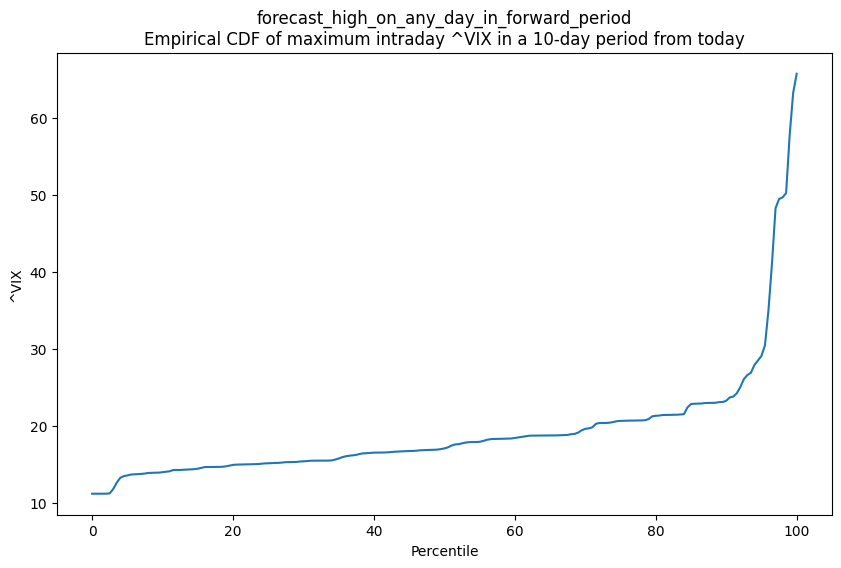

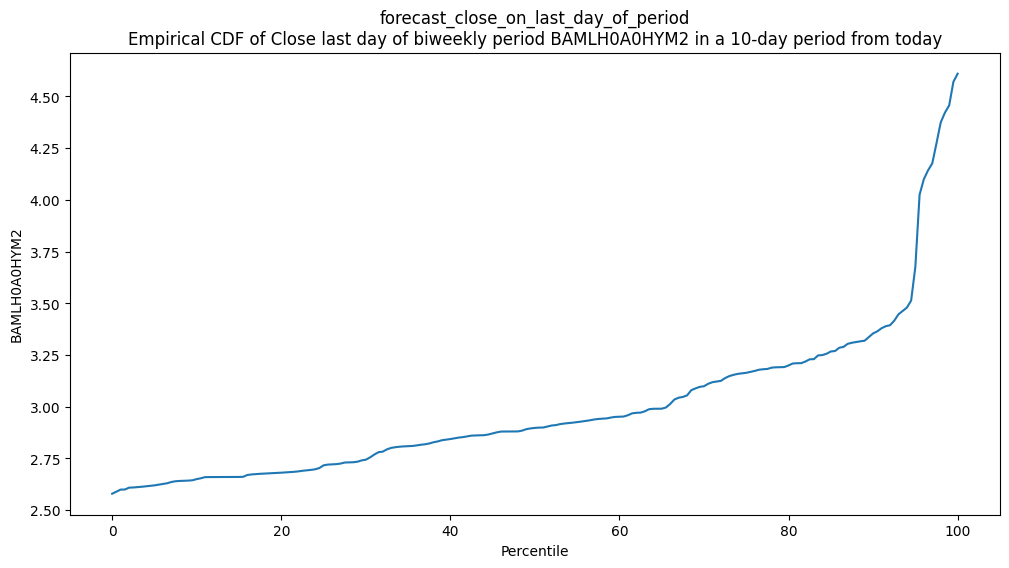

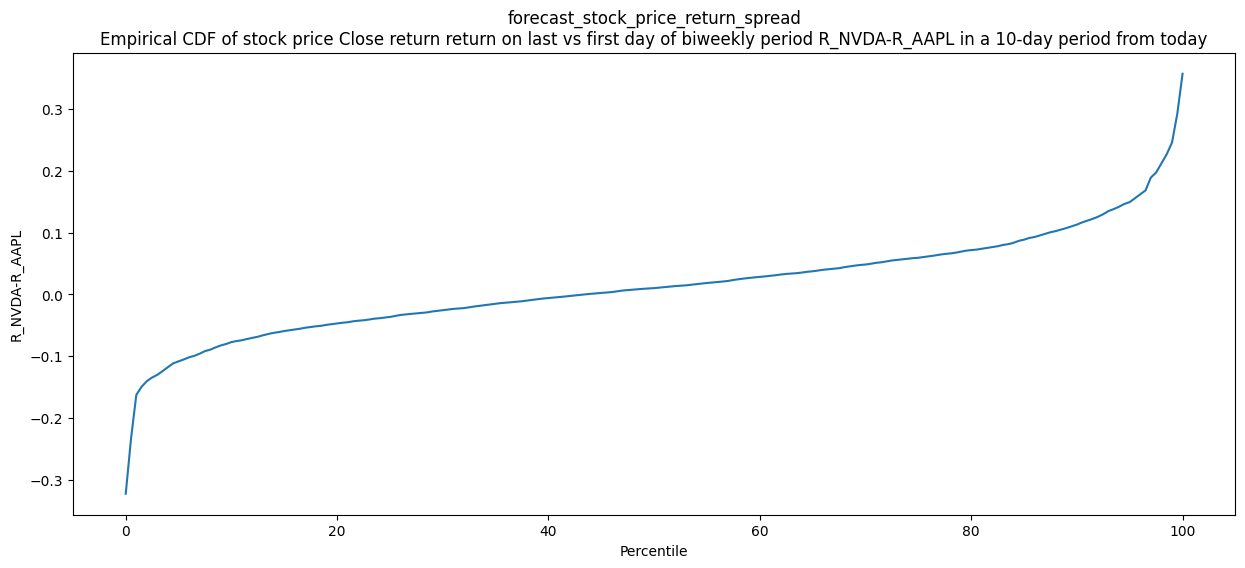

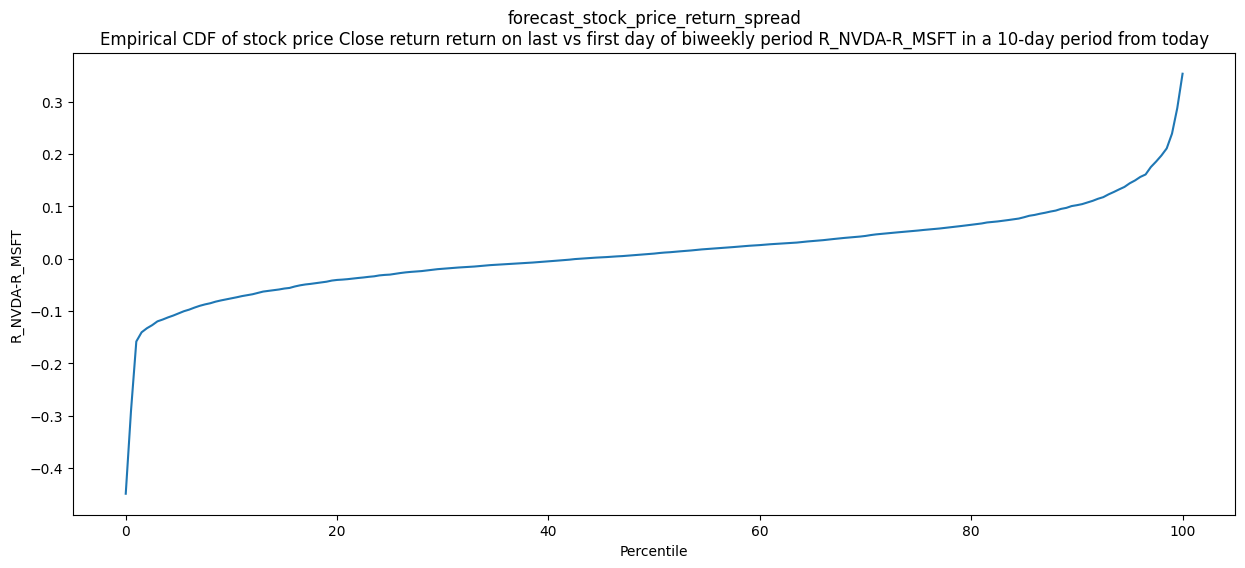

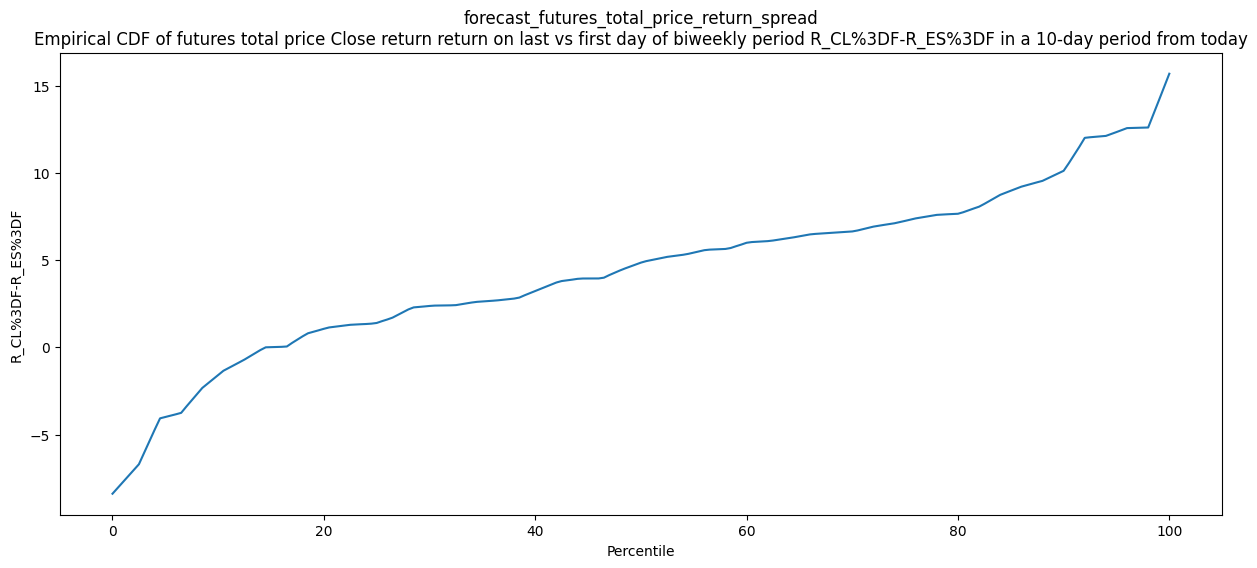

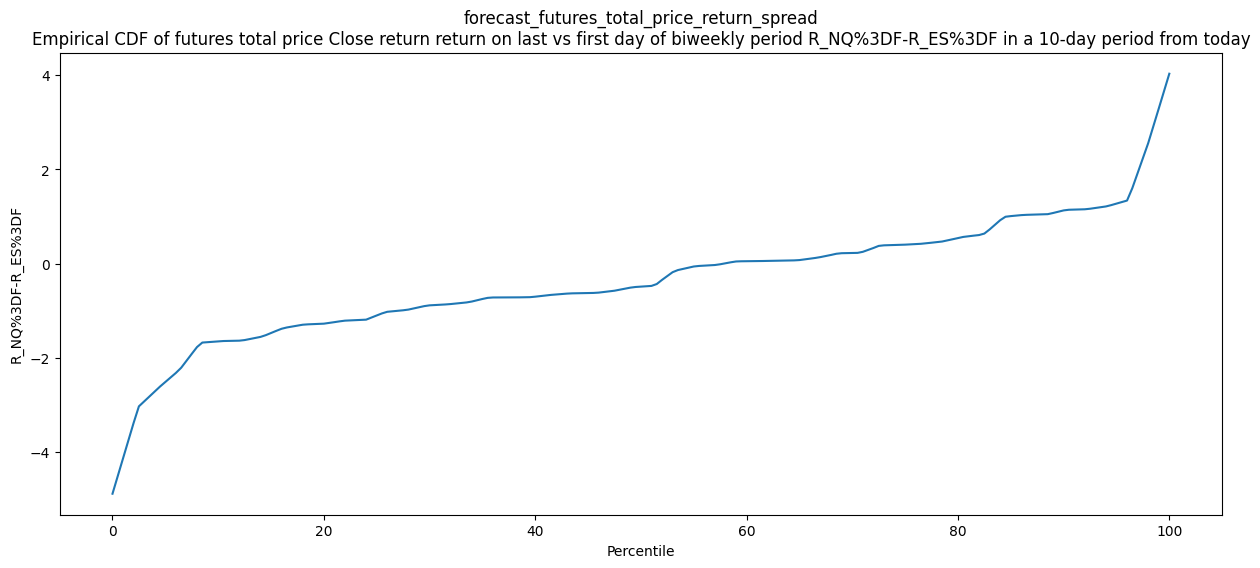

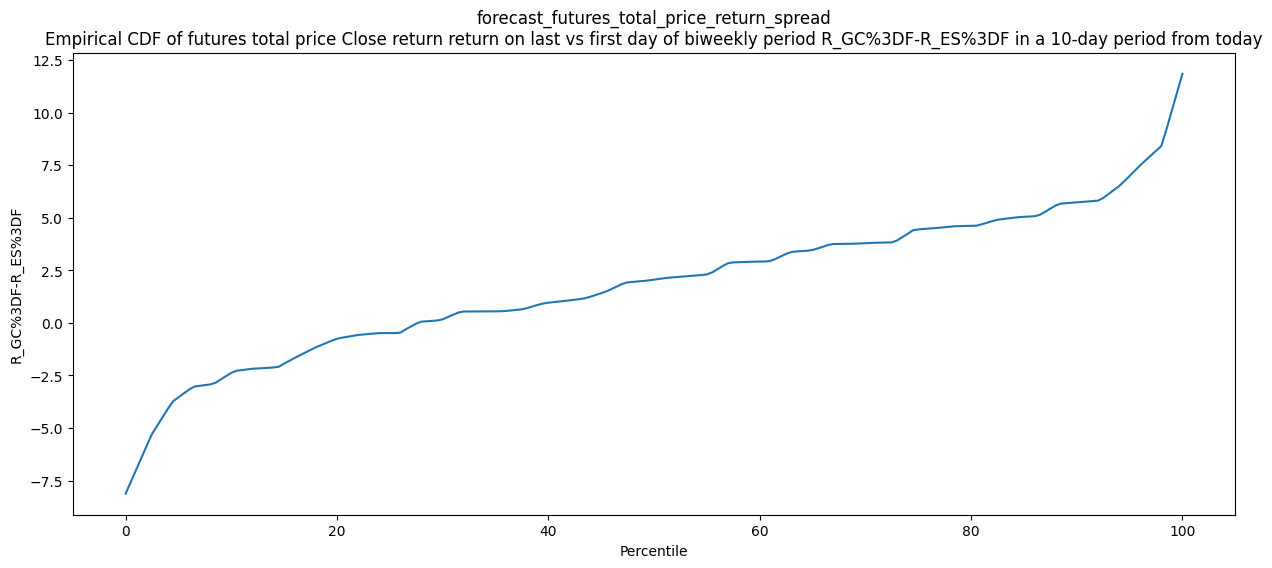

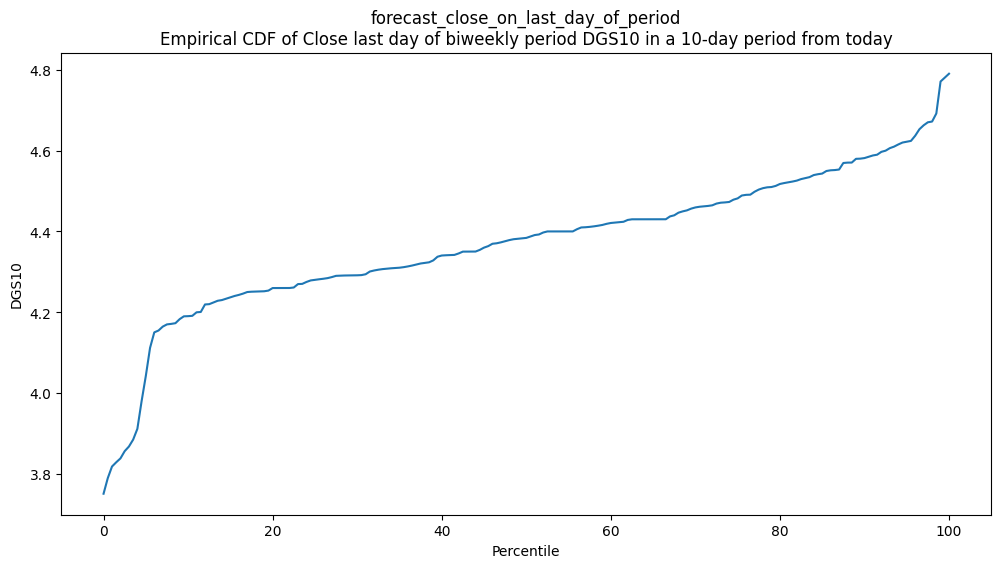

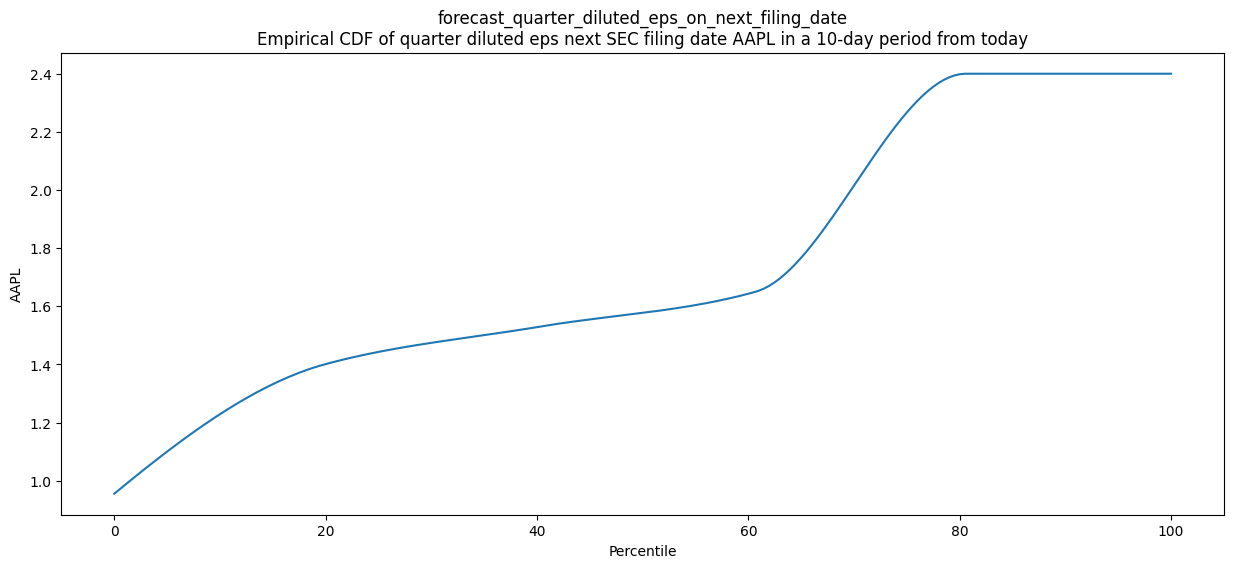

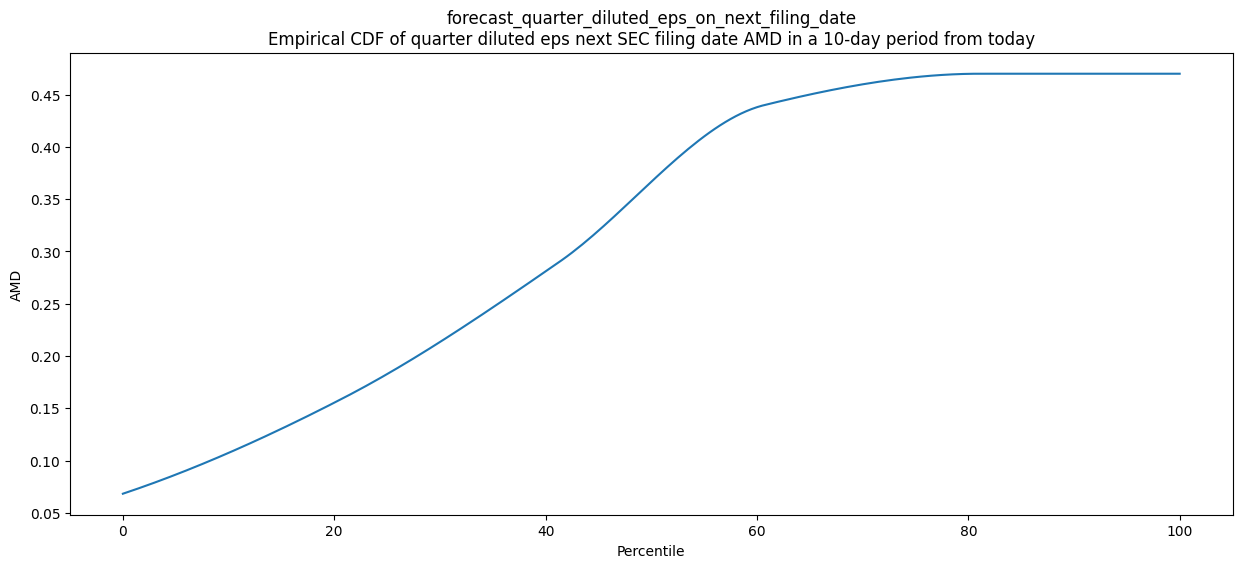

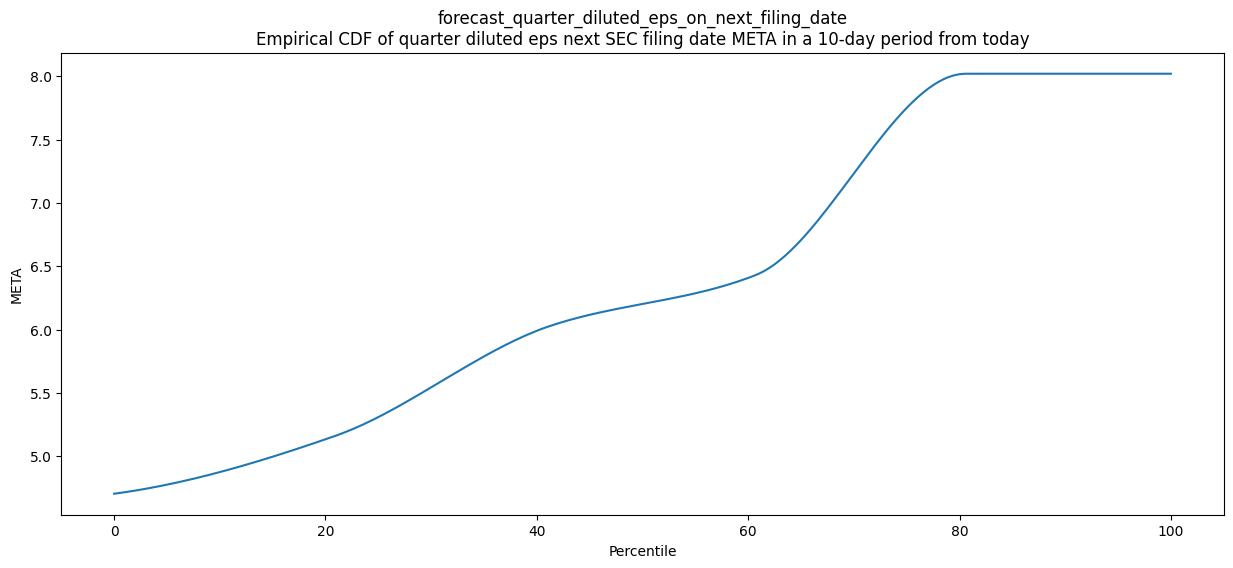

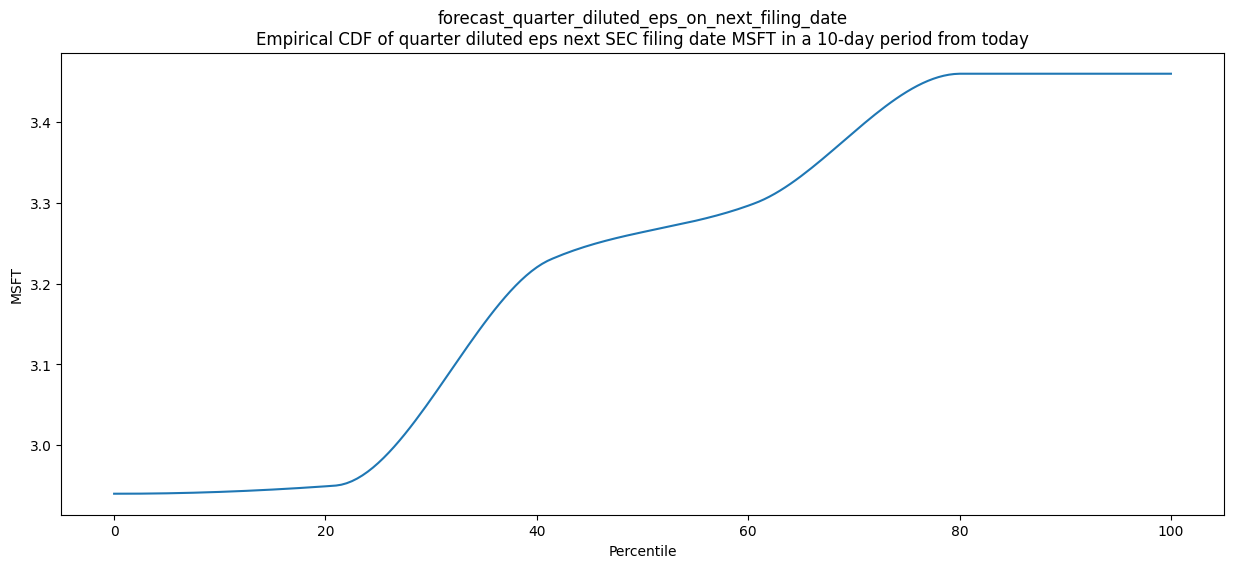

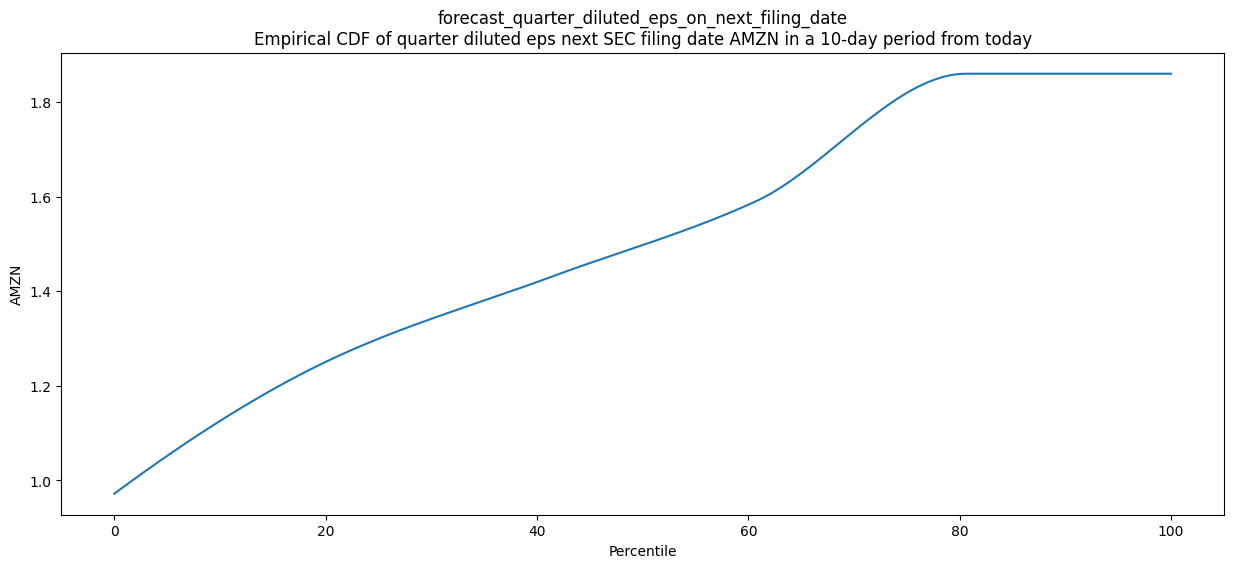

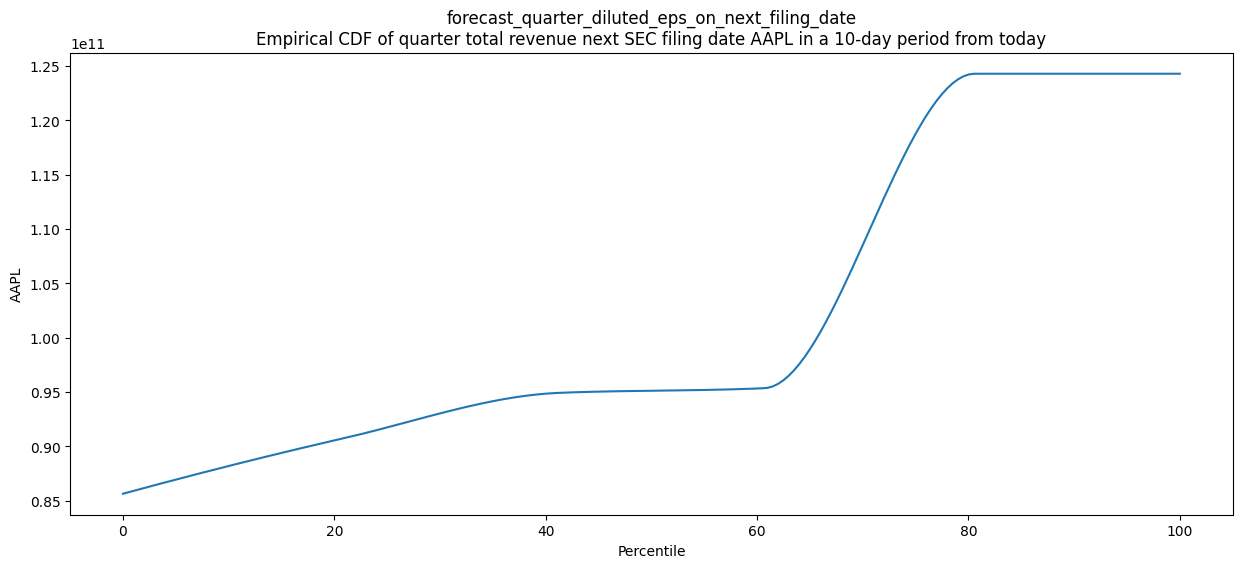

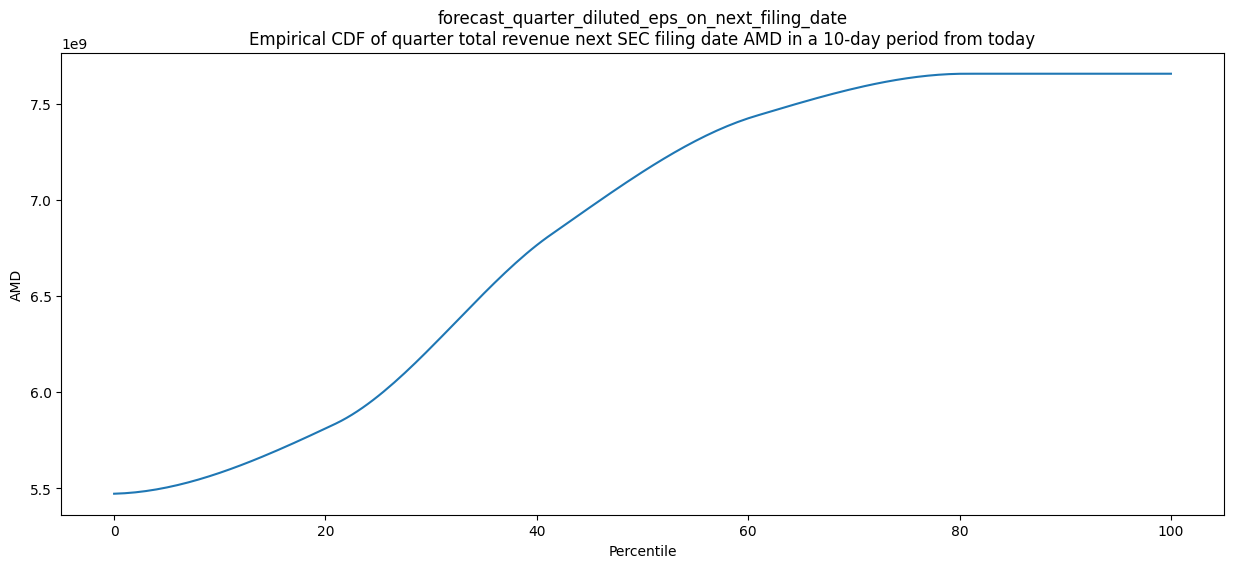

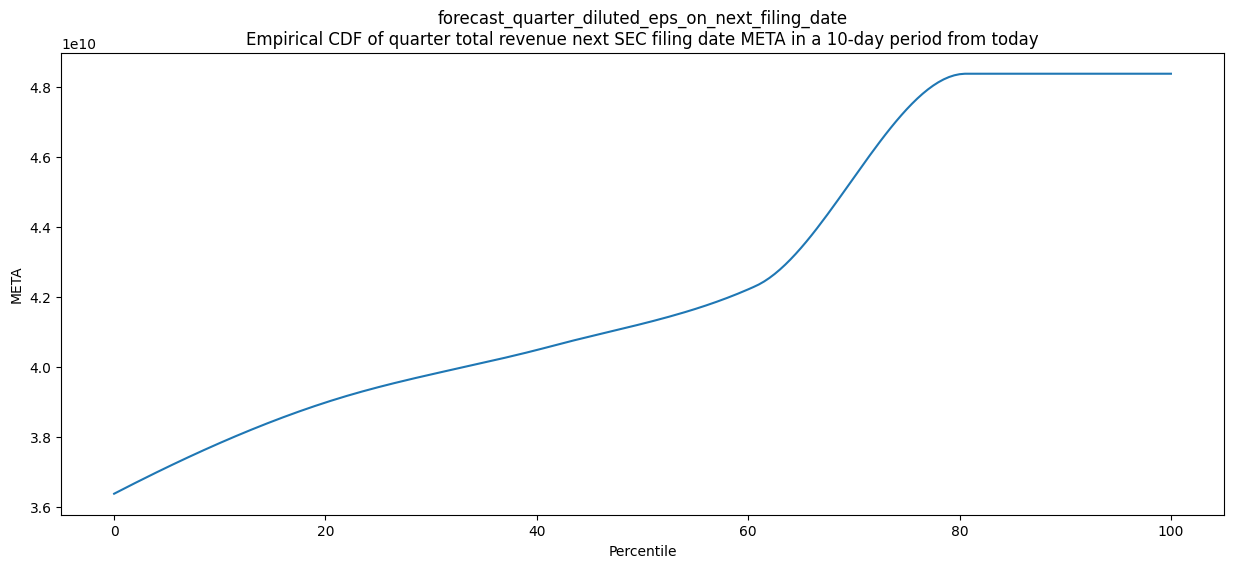

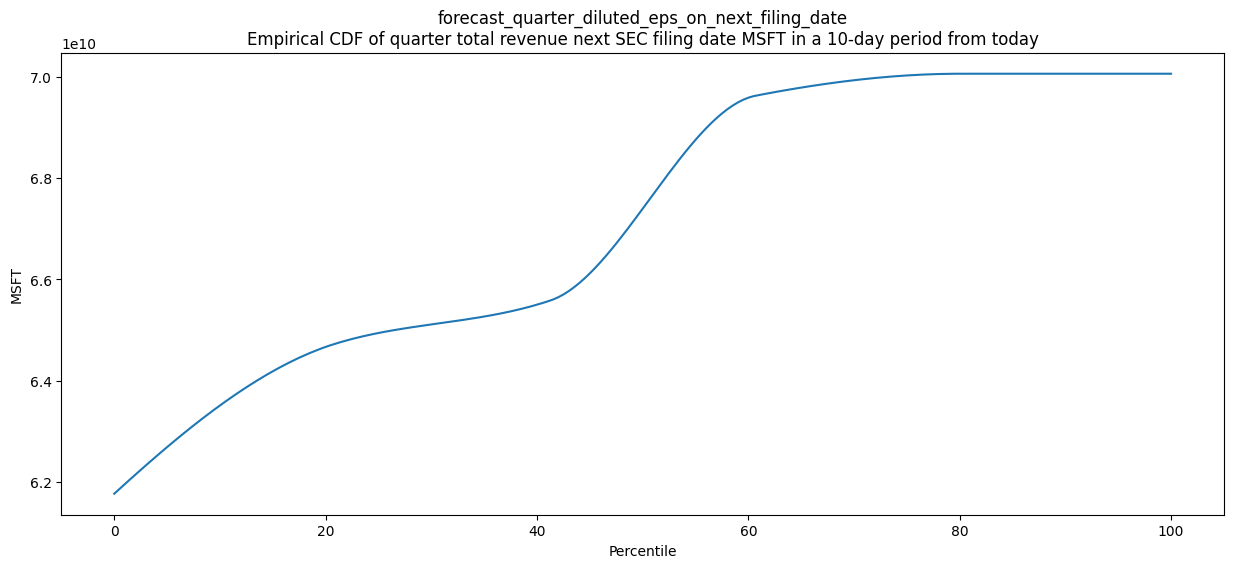

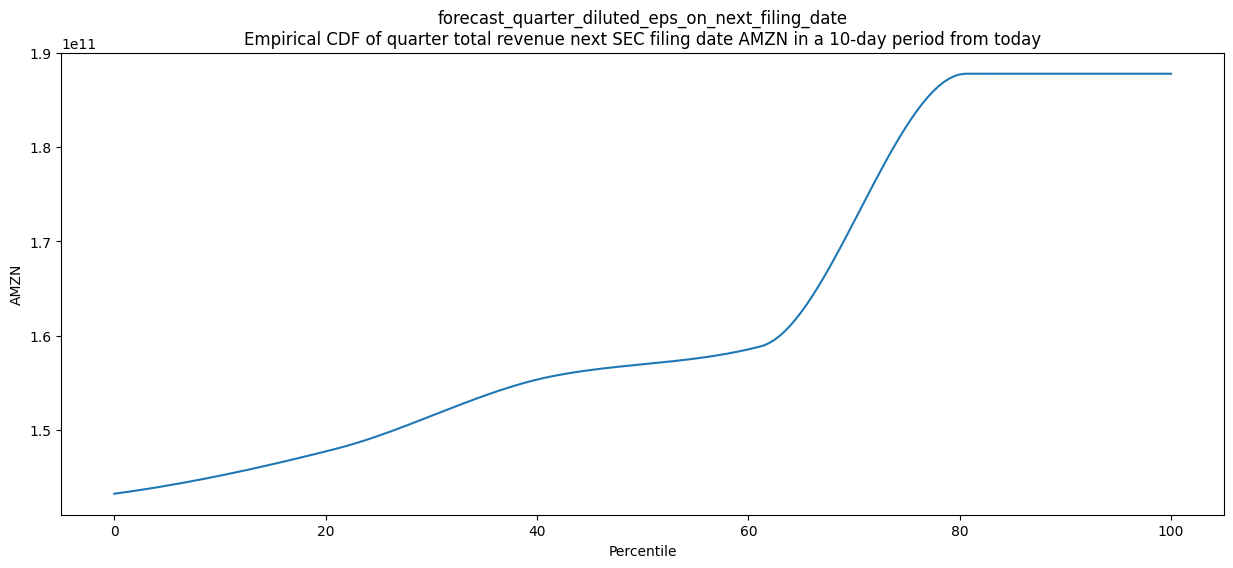

In [9]:
for i, ifp in enumerate(ifps):
    fn = 'glimt/forecast/{ifp["id"]}.json'
    if os.path.exists(fn):
        print(fn)
        continue
    # Generate forecast for each question
    print(f"[{i}] {ifp['title']}")
    ifp['forecast'] = """Statistical analysis."""
    ifp['question_type'] = 'numeric'
    ### High on any day in forward biweekly period from today
    (observable, period_type) = (ifp['observable'], ifp['period_type'])
    if observable == 'High' and period_type == 'any day in biweekly period':
        print("******forecast_high_on_any_day_in_forward_period")
        rng, prediction = forecast_high_on_any_day_in_forward_period(ifp)
    ### Close on last day of biweekly period
    elif observable == 'Close' and period_type == 'last day of biweekly period':
        print("******forecast_close_on_last_day_of_period")
        rng, prediction = forecast_close_on_last_day_of_period(ifp)
    ### period stock price return on last vs first day of biweekly period
    elif (observable, period_type) == ('stock price Close return', 'return on last vs first day of biweekly period'):
        print("*** forecast_stock_price_return_spread")
        rng, prediction = forecast_stock_price_return_spread(ifp)
    ### period futures total price return on last vs first day of biweekly period
    elif (observable, period_type) == ('futures total price Close return', 'return on last vs first day of biweekly period'):
        print("*******forecast_futures_total_price_return_spread")
        rng, prediction = forecast_futures_total_price_return_spread(ifp)
    ### quarter diluted eps on next SEC filing date	
    elif (observable, period_type) == ('quarter diluted eps', 'next SEC filing date'):
        print("********forecast_quarter_diluted_eps_on_next_filing_date")
        rng, prediction = forecast_quarter_diluted_eps_on_next_filing_date(ifp)
    ### quarter total revenue on next SEC filing date	
    elif (observable, period_type)  == ('quarter total revenue', 'next SEC filing date'):
        print("*********forecast_quarter_diluted_eps_on_next_filing_date")
        rng, prediction = forecast_quarter_diluted_eps_on_next_filing_date(ifp)
    elif ifp['title'].startswith('Will '):
        forecast_general_binary(ifp)
        continue
    else:
        raise Exception(f"Unhandled question [{ifp['id']}] {ifp['title']} {observable} {period_type}")
    ifp['prediction'] = prediction

In [12]:
from smooth_percentiles import smooth_percentiles

for i, ifp in enumerate(ifps):
    if type(ifp['prediction']) == float:
        ifp['question_type'] = 'binary'
    # Submit the question
    row = pd.Series()
    row['id_of_question'] = ifp['id']
    row['id_of_post'] = ifp['post_id']
    row['question_type'] = ifp['question_type']
    row['forecast'] = ifp['forecast']
    if ifp['question_type'] == 'numeric':
        p1 = ifp['prediction']
        p1[0] = ifp['scaling']['range_min']
        p1[-1] = ifp['scaling']['range_max']
        p1 = ensure_min_increase(p1)
        p2 = dict(zip(rng,p1))
        p4 = metaculus_generate_continuous_cdf(p2, ifp)
        p5 = standardize_cdf(p4, ifp['scaling'])
        row['prediction'] = p5
    elif ifp['question_type'] == 'binary':
        continue # already posted
    else:
        raise Exception(ifp['question_type'])
    try:
        post_group_forecast(row)
    except Exception as e:
        print("An error occurred:", e)

Prediction Post status code: 201
Posted forecast for 38212
Prediction Post status code: 201
Posted forecast for 38213
Prediction Post status code: 201
Posted forecast for 38207
Prediction Post status code: 201
Posted forecast for 38208
Prediction Post status code: 201
Posted forecast for 38209
Prediction Post status code: 201
Posted forecast for 38211
Prediction Post status code: 201
Posted forecast for 38210
Prediction Post status code: 201
Posted forecast for 38214
Prediction Post status code: 201
Posted forecast for 38165
Prediction Post status code: 201
Posted forecast for 38166
Prediction Post status code: 201
Posted forecast for 38167
Prediction Post status code: 201
Posted forecast for 38168
Prediction Post status code: 201
Posted forecast for 38267
Prediction Post status code: 201
Posted forecast for 38169
Prediction Post status code: 201
Posted forecast for 38170
Prediction Post status code: 201
Posted forecast for 38171
Prediction Post status code: 201
Posted forecast for 381